# Construcción de la red bipartita autor-video


**Definición de la red:**
- Un conjunto de nodos son **autores** (author_channel_id), el otro son **videos** (video_id).
- Existe una arista entre un autor y un video si ese autor publicó al menos un comentario en ese video.
- El **peso** de la arista es el número de comentarios que ese autor escribió en ese video.
- La red es **bipartita**: nunca hay aristas autor-autor ni video-video en este grafo.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Carga de los datos limpios

Se parte de los archivos ya integrados y limpiados en los puntos 1 y 2 del laboratorio.

In [2]:
comments = pd.read_csv('youtube_comments_clean.csv')
videos = pd.read_csv('youtube_videos_clean.csv')

print(f"Comentarios: {comments.shape[0]} filas, {comments.shape[1]} columnas")
print(f"Videos: {videos.shape[0]} filas, {videos.shape[1]} columnas")
print(f"Autores únicos que comentaron: {comments['author_channel_id'].nunique()}")
print(f"Videos con al menos un comentario: {comments['video_id'].nunique()}")

Comentarios: 406 filas, 24 columnas
Videos: 293 filas, 21 columnas
Autores únicos que comentaron: 332
Videos con al menos un comentario: 19


## 2. Construcción de la tabla de aristas

Cada arista corresponde a un par único (`author_channel_id`, `video_id`). El peso es el
conteo de comentarios de ese autor en ese video. Adicionalmente se guarda la suma de
`like_count` de esos comentarios como atributo descriptivo de la arista (no como parte
de la definición del peso, que el enunciado fija como número de comentarios).

In [3]:
edges_df = (
    comments
    .groupby(['author_channel_id', 'video_id'], as_index=False)
    .agg(
        weight=('comment_id', 'count'),
        likes_totales=('like_count', 'sum'),
    )
)
edges_df['tipo_arista'] = 'autor_comento_video'

print(f"Número de aristas (pares autor-video únicos): {edges_df.shape[0]}")
print(f"Suma de pesos == total de comentarios: {edges_df['weight'].sum() == len(comments)}")
print(f"Distribución del peso de las aristas:")
print(edges_df['weight'].value_counts().sort_index())

edges_df.head()

Número de aristas (pares autor-video únicos): 343
Suma de pesos == total de comentarios: True
Distribución del peso de las aristas:
weight
1    303
2     28
3      7
4      1
5      2
6      2
Name: count, dtype: int64


,author_channel_id,video_id,weight,likes_totales,tipo_arista
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1,0,autor_comento_video
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1,1,autor_comento_video
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2,0,autor_comento_video
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1,6,autor_comento_video
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1,6,autor_comento_video


## 3. Construcción del grafo bipartito

Se agregan primero todos los nodos autor y todos los nodos video (con sus atributos),
y luego las aristas con su peso. Cada nodo lleva el atributo `bipartite` para identificar
a qué conjunto pertenece.

In [4]:
B = nx.Graph()

# --- nodos autor ---
autores_info = comments[['author_channel_id', 'author_name']].drop_duplicates()
for _, row in autores_info.iterrows():
    B.add_node(
        row['author_channel_id'],
        bipartite='autor',
        label=row['author_name'],
    )

# --- nodos video (solo los videos que efectivamente tienen comentarios) ---
videos_comentados = videos[videos['video_id'].isin(comments['video_id'])].copy()
for _, row in videos_comentados.iterrows():
    B.add_node(
        row['video_id'],
        bipartite='video',
        label=row['title'],
        channel_name=row['channel_name'],
        channel_id=row['channel_id'],
        category=row['category'],
        view_count=row['view_count'],
    )

# --- aristas ---
for _, row in edges_df.iterrows():
    B.add_edge(
        row['author_channel_id'], row['video_id'],
        weight=int(row['weight']),
        likes_totales=int(row['likes_totales']),
    )

print(f"Nodos totales: {B.number_of_nodes()}")
print(f"Aristas totales: {B.number_of_edges()}")
print(f"¿Es bipartito?: {nx.is_bipartite(B)}")

Nodos totales: 351
Aristas totales: 343
¿Es bipartito?: True


In [5]:
autor_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'autor']
video_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'video']

print(f"Nodos tipo autor: {len(autor_nodes)}")
print(f"Nodos tipo video: {len(video_nodes)}")
print(f"Total de comentarios en dataset original: {len(comments)} -> coincide con suma de pesos de aristas")

Nodos tipo autor: 332
Nodos tipo video: 19
Total de comentarios en dataset original: 406 -> coincide con suma de pesos de aristas


## 4. Tabla de nodos y tabla de aristas

Se entregan ambas tablas en un único DataFrame de nodos (columna `tipo` distingue autor/video)
y un DataFrame de aristas independiente, junto con sus versiones exportadas a CSV.

In [6]:
grado = dict(B.degree())
grado_ponderado = dict(B.degree(weight='weight'))

filas_nodos = []
for n, d in B.nodes(data=True):
    filas_nodos.append({
        'node_id': n,
        'tipo': d['bipartite'],
        'label': d.get('label'),
        'grado': grado[n],
        'peso_total': grado_ponderado[n],
        'channel_name': d.get('channel_name'),
        'category': d.get('category'),
        'view_count': d.get('view_count'),
    })

nodes_df = pd.DataFrame(filas_nodos)

print("Resumen de nodos por tipo:")
print(nodes_df['tipo'].value_counts())
print()
print("Nodos con mayor peso total (videos más comentados / autores más activos):")
nodes_df.sort_values('peso_total', ascending=False).head(10)

Resumen de nodos por tipo:
tipo
autor    332
video     19
Name: count, dtype: int64

Nodos con mayor peso total (videos más comentados / autores más activos):


,node_id,tipo,label,grado,peso_total,channel_name,category,view_count
346,n8iP75gIpmw,video,Qué rico come tu diputado,128,161,Quorum,News & Politics,11775.0
344,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,Quorum,News & Politics,10156.0
334,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puent...,32,45,Gobierno de la República de Guatemala,Entertainment,11670.0
336,OkXlHx0hx-8,video,EE.UU. envía a mexicanos deportados a Guatemal...,18,25,Noticias Telemundo,News & Politics,14200.0
345,lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,25,25,Municipalidad de Guatemala,News & Politics,304089.0
337,PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemal...,19,25,Gobierno de la República de Guatemala,Entertainment,3628.0
349,yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,16,16,Quorum,News & Politics,1954.0
332,06mFNPU0aB8,video,Capturan a presuntos delincuentes disfrazados ...,13,14,Noti7,News & Politics,6692.0
347,ndAZjHqzzT8,video,Internet: escoger el menos malo,10,12,Quorum,News & Politics,717.0
343,is3Mk5oC19g,video,Capturan a ladrón que había quedado grabado mi...,7,7,TN23 Guatemala,News & Politics,4616.0


In [7]:
edges_df.rename(columns={'author_channel_id': 'source', 'video_id': 'target'}, inplace=True)

print("Tabla de aristas (primeras filas):")
edges_df.head(10)

Tabla de aristas (primeras filas):


,source,target,weight,likes_totales,tipo_arista
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1,0,autor_comento_video
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1,1,autor_comento_video
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2,0,autor_comento_video
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1,6,autor_comento_video
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1,6,autor_comento_video
5,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1,2,autor_comento_video
6,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1,5,autor_comento_video
7,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1,0,autor_comento_video
8,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1,3,autor_comento_video
9,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1,113,autor_comento_video


In [8]:
nodes_df.to_csv('red_bipartita_nodos.csv', index=False)
edges_df.to_csv('red_bipartita_aristas.csv', index=False)
print("Tablas exportadas: red_bipartita_nodos.csv, red_bipartita_aristas.csv")

Tablas exportadas: red_bipartita_nodos.csv, red_bipartita_aristas.csv


## 5. Visualización de la red completa

Se visualizan **todos** los nodos y aristas (332 autores + 19 videos), sin filtrar ni podar
la red por estética. Para que la lectura sea posible:
- Los videos (hub) se dibujan más grandes, en rojo, y con su título como etiqueta.
- Los autores se dibujan pequeños, en azul, sin etiqueta individual (serían 332 etiquetas ilegibles).
- El grosor/transparencia de las aristas es bajo porque la mayoría tiene peso 1.

Esto no elimina estructura: cada nodo y cada arista de la red original sigue presente en el dibujo.

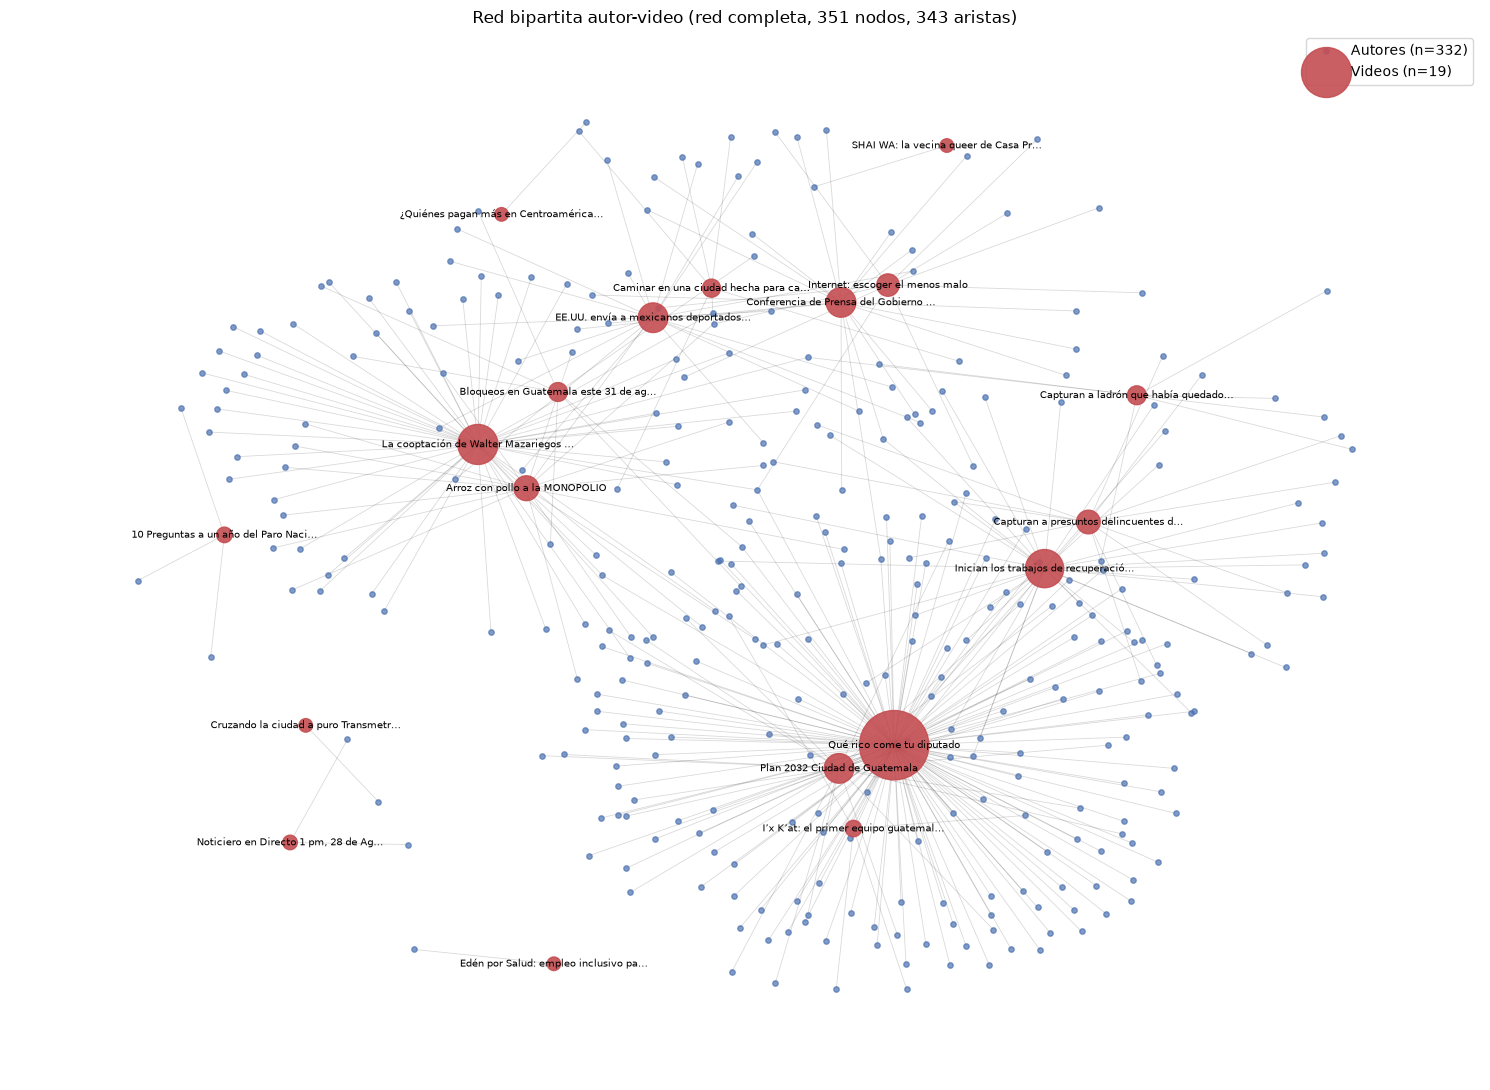

In [9]:
pos = nx.spring_layout(B, k=0.25, seed=42, weight='weight')

video_sizes = [80 + 15 * B.degree(n, weight='weight') for n in video_nodes]

fig, ax = plt.subplots(figsize=(15, 11))
nx.draw_networkx_edges(B, pos, alpha=0.15, width=0.6, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=autor_nodes, node_color='#4C72B0',
                        node_size=15, alpha=0.7, label=f'Autores (n={len(autor_nodes)})', ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=video_nodes, node_color='#C44E52',
                        node_size=video_sizes, alpha=0.9, label=f'Videos (n={len(video_nodes)})', ax=ax)

labels = {n: (B.nodes[n]['label'][:35] + '…' if len(B.nodes[n]['label']) > 35 else B.nodes[n]['label'])
          for n in video_nodes}
nx.draw_networkx_labels(B, pos, labels=labels, font_size=7, ax=ax)

ax.legend(scatterpoints=1, loc='upper right')
ax.set_title('Red bipartita autor-video (red completa, 351 nodos, 343 aristas)')
ax.axis('off')
plt.tight_layout()
plt.savefig('red_bipartita_completa.png', dpi=150)
plt.show()